# 06 — Loss Estimation & Replacement Cost

**Purpose:** Demonstrate bridge replacement cost value (RCV) estimation using the
FHWA 2024 state-level unit cost model and compute expected earthquake losses
for the Northridge study region.

## Input Files

| File | Format | Description |
|------|--------|-------------|
| `config.yaml` | YAML | Analysis configuration (region, IM source, etc.) |
| `data/grid.xml` | XML (USGS ShakeMap) | Ground motion grid for Northridge 1994 |
| `data/CA24.txt` | Fixed-width (FHWA NBI) | California bridge inventory |

## Outputs

| Object | Type | Description |
|--------|------|-------------|
| `portfolio_fhwa` | `list[BridgeExposure]` | Bridges with FHWA 2024 RCV estimates |
| `loss_df` | `pd.DataFrame` | Per-bridge expected loss, loss ratio, damage state |

## Key Concepts

- **RCV formula:** `deck_area x base_unit_cost x f_material x f_span x f_skew x f_seismic`
- **Damage ratios:** Hazus 6.1 Table 7.11 (repair cost as fraction of RCV)
- **Expected loss:** `E[Loss] = SUM P(DS) x DR(DS) x RCV`
- **Data source:** FHWA Bridge Replacement Unit Costs 2024 (fhwa.dot.gov/bridge/nbi/sd2024.cfm)

## Imports & Setup

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config, CostConfig, IM_COLUMN_MAP
from src.data_loader import load_shakemap, load_nbi, classify_nbi_to_hazus
from src.interpolation import interpolate_im
from src.exposure import (estimate_replacement_cost, estimate_replacement_cost_fhwa,
                          create_portfolio_from_nbi, portfolio_summary)
from src.fragility import damage_state_probabilities
from src.loss import HAZUS_DAMAGE_RATIOS, HAZUS_DOWNTIME_DAYS

%matplotlib inline

## Step 1: FHWA 2024 Cost Model

The FHWA publishes state-level bridge replacement unit costs annually. The 2024 edition
provides separate rates for NHS (National Highway System) and Non-NHS bridges in **$/ft²** of
deck area, which we convert to **$/m²**.

The replacement cost value (RCV) for a single bridge is:

```
RCV = deck_area × base_unit_cost × f_material × f_span × f_skew × f_seismic
```

where each `f_*` factor adjusts the base rate for bridge-specific characteristics.

**Reference:** FHWA Bridge Replacement Unit Costs 2024 — fhwa.dot.gov/bridge/nbi/sd2024.cfm

In [2]:
# FHWA 2024 state-level bridge replacement unit costs
fhwa_rates = {
    "California": {"NHS": 465, "Non-NHS": 483, "USD_per_m2": 5005},
    "Texas": {"NHS": 109, "Non-NHS": 125, "USD_per_m2": 1173},
    "New York": {"NHS": 792, "Non-NHS": 524, "USD_per_m2": 8525},
    "Florida": {"NHS": 244, "Non-NHS": 277, "USD_per_m2": 2627},
    "National Avg": {"NHS": 429, "Non-NHS": 383, "USD_per_m2": 4618},
}
rates_df = pd.DataFrame(fhwa_rates).T
rates_df.columns = ["NHS ($/ft²)", "Non-NHS ($/ft²)", "Rate ($/m²)"]
print("FHWA 2024 Bridge Replacement Unit Costs")
print("Source: fhwa.dot.gov/bridge/nbi/sd2024.cfm")
display(rates_df)

FHWA 2024 Bridge Replacement Unit Costs
Source: fhwa.dot.gov/bridge/nbi/sd2024.cfm


,NHS ($/ft²),Non-NHS ($/ft²),Rate ($/m²)
California,465,483,5005
Texas,109,125,1173
New York,792,524,8525
Florida,244,277,2627
National Avg,429,383,4618


## Step 2: Adjustment Factors

The base unit cost is adjusted by four multiplicative factors:

| Factor | Source | Rationale |
|--------|--------|-----------|
| **Material** (`f_material`) | Caltrans Comparative Bridge Costs 2022 | Steel costs more than concrete; wood costs less |
| **Span complexity** (`f_span`) | Mackie & Stojadinovic (2010) | Longer spans require deeper girders and more complex foundations |
| **Skew angle** (`f_skew`) | Mackie & Stojadinovic (2010) | Skewed bridges need custom formwork and bearings |
| **Seismic design era** (`f_seismic`) | Engineering judgment | Post-1990 bridges built to modern seismic codes cost more to replace in kind |

In [3]:
cc = CostConfig()
print(f"Base unit cost: ${cc.base_unit_cost:,.0f}/m² (CA NHS, FHWA 2024)")
print()

# Material factors
print("Material Factors (relative to FHWA blended average):")
print("  Source: Caltrans Comparative Bridge Costs 2022")
for mat, factor in cc.material_factors.items():
    print(f"  {mat:<25} {factor:.2f}")
print()

# Span complexity
print("Span Complexity Factors:")
labels = ["< 30m", "30-60m", "60-120m", "> 120m"]
for label, factor in zip(labels, cc.span_factors):
    print(f"  Max span {label:<10} {factor:.2f}")
print()

# Skew
print("Skew Angle Factors:")
labels = ["< 15°", "15-30°", "30-45°", "> 45°"]
for label, factor in zip(labels, cc.skew_factors):
    print(f"  Skew {label:<10} {factor:.2f}")
print()

# Seismic era
print("Seismic Design Era Factors:")
for era, factor in cc.seismic_era_factors.items():
    print(f"  {era:<15} {factor:.2f}")

Base unit cost: $5,005/m² (CA NHS, FHWA 2024)

Material Factors (relative to FHWA blended average):
  Source: Caltrans Comparative Bridge Costs 2022
  concrete                  0.90
  steel                     1.15
  prestressed_concrete      1.00
  wood                      0.65
  other                     0.95

Span Complexity Factors:
  Max span < 30m      1.00
  Max span 30-60m     1.10
  Max span 60-120m    1.25
  Max span > 120m     1.50

Skew Angle Factors:
  Skew < 15°      1.00
  Skew 15-30°     1.05
  Skew 30-45°     1.10
  Skew > 45°      1.20

Seismic Design Era Factors:
  pre_1975        1.00
  1975_1990       1.10
  post_1990       1.15


## Step 3: Load Bridges & Compute RCV

We load the NBI inventory, classify bridges into Hazus HWB classes, then build two
portfolios for comparison:

1. **Legacy model** — simple `material × deck_area` unit cost (no adjustment factors)
2. **FHWA 2024 model** — full multi-factor RCV with material, span, skew, and seismic era adjustments

In [4]:
cfg = load_config(PROJECT_ROOT / "config.yaml")
nbi = load_nbi(PROJECT_ROOT / "data" / "CA24.txt", northridge_bbox=cfg.region)
nbi = classify_nbi_to_hazus(nbi)

# FHWA portfolio
portfolio_fhwa = create_portfolio_from_nbi(nbi, cost_config=CostConfig())
ps_fhwa = portfolio_summary(portfolio_fhwa)

# Legacy portfolio
portfolio_legacy = create_portfolio_from_nbi(nbi)
ps_legacy = portfolio_summary(portfolio_legacy)

print(f"Bridges: {ps_fhwa['n_bridges']}")
print(f"\n{'Model':<20} {'Total RCV':>20} {'Avg RCV/Bridge':>20}")
print("-" * 62)
print(f"{'Legacy':<20} ${ps_legacy['total_replacement_cost']:>19,.0f} ${ps_legacy['avg_replacement_cost']:>19,.0f}")
print(f"{'FHWA 2024':<20} ${ps_fhwa['total_replacement_cost']:>19,.0f} ${ps_fhwa['avg_replacement_cost']:>19,.0f}")
print(f"{'Ratio':<20} {'':>20} {ps_fhwa['avg_replacement_cost']/ps_legacy['avg_replacement_cost']:>19.2f}x")

Bridges: 2953

Model                           Total RCV       Avg RCV/Bridge
--------------------------------------------------------------
Legacy               $     17,216,910,160 $          5,830,312
FHWA 2024            $     28,877,691,033 $          9,779,103
Ratio                                                    1.68x


## Step 4: RCV Distribution

Three views of the replacement cost distribution:
1. **Histogram** -- overall RCV distribution across all bridges
2. **By material** -- box plots showing how material type drives cost differences
3. **Skew vs cost** -- scatter plot showing the skew angle adjustment effect

C:\Users\wenyu\AppData\Local\Temp\ipykernel_115296\2537777454.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([mat_costs[m] for m in mat_names], labels=mat_names)


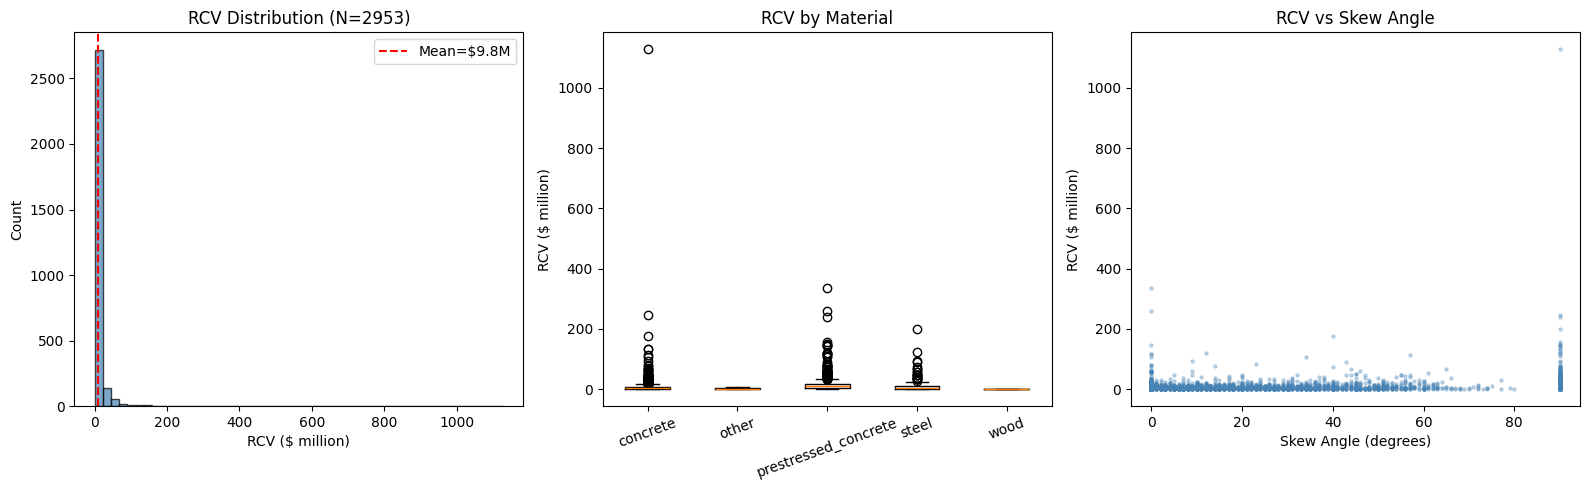

In [5]:
costs = [b.replacement_cost for b in portfolio_fhwa]
materials = [b.material for b in portfolio_fhwa]
skews = [b.skew_angle for b in portfolio_fhwa]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
ax = axes[0]
ax.hist(np.array(costs) / 1e6, bins=50, color="steelblue", edgecolor="k", alpha=0.7)
ax.set_xlabel("RCV ($ million)")
ax.set_ylabel("Count")
ax.set_title(f"RCV Distribution (N={len(costs)})")
ax.axvline(np.mean(costs)/1e6, color="red", ls="--", label=f"Mean=${np.mean(costs)/1e6:.1f}M")
ax.legend()

# By material
ax = axes[1]
mat_costs = {}
for b in portfolio_fhwa:
    mat_costs.setdefault(b.material, []).append(b.replacement_cost / 1e6)
mat_names = sorted(mat_costs.keys())
ax.boxplot([mat_costs[m] for m in mat_names], labels=mat_names)
ax.set_ylabel("RCV ($ million)")
ax.set_title("RCV by Material")
ax.tick_params(axis='x', rotation=20)

# Skew angle vs cost
ax = axes[2]
ax.scatter(skews, np.array(costs)/1e6, s=5, alpha=0.3, c="steelblue")
ax.set_xlabel("Skew Angle (degrees)")
ax.set_ylabel("RCV ($ million)")
ax.set_title("RCV vs Skew Angle")

plt.tight_layout()
plt.show()

## Step 5: Damage Ratios (Hazus Table 7.11)

The Hazus earthquake model defines five damage states for bridges, each with a
**damage ratio** (repair cost as a fraction of RCV) and an estimated **restoration time**.

These ratios translate damage state probabilities into dollar losses:

```
E[Loss] = SUM_ds  P(ds) * DR(ds) * RCV
```

In [6]:
print("Hazus 6.1 Damage Ratios (Table 7.11):")
print(f"{'Damage State':<15} {'Repair/RCV':>10} {'Downtime (days)':>15}")
print("-" * 42)
ds_order = ["none", "slight", "moderate", "extensive", "complete"]
for ds in ds_order:
    print(f"{ds.capitalize():<15} {HAZUS_DAMAGE_RATIOS[ds]:>10.0%} {HAZUS_DOWNTIME_DAYS[ds]:>15.1f}")
print()
print("E[Loss] = SUM P(DS) * DR(DS) * RCV")
print("Source: FEMA Hazus 6.1 Earthquake Technical Manual, Chapter 7")

Hazus 6.1 Damage Ratios (Table 7.11):
Damage State    Repair/RCV Downtime (days)
------------------------------------------
None                    0%             0.0
Slight                  3%             0.6
Moderate                8%             2.5
Extensive              25%            75.0
Complete              100%           230.0

E[Loss] = SUM P(DS) * DR(DS) * RCV
Source: FEMA Hazus 6.1 Earthquake Technical Manual, Chapter 7


## Step 6: Expected Loss per Bridge

For each bridge we:
1. Interpolate Sa(1.0s) from the ShakeMap grid to the bridge location
2. Compute damage state probabilities using the HWB-class fragility curves
3. Multiply each P(DS) by the damage ratio and RCV to get expected loss

In [7]:
# Get ShakeMap Sa for each bridge
grid = load_shakemap(PROJECT_ROOT / "data" / "grid.xml")
im_col = IM_COLUMN_MAP.get(cfg.im_type, "PSA10")
sa_arr = interpolate_im(
    grid["LAT"].values, grid["LON"].values, grid[im_col].values,
    nbi["latitude"].values, nbi["longitude"].values,
    method="nearest",
)

# Compute per-bridge loss
results = []
for i, (_, row) in enumerate(nbi.iterrows()):
    b = portfolio_fhwa[i]
    probs = damage_state_probabilities(sa_arr[i], row["hwb_class"])
    loss = sum(probs[ds] * HAZUS_DAMAGE_RATIOS[ds] * b.replacement_cost for ds in ds_order)
    loss_ratio = loss / b.replacement_cost if b.replacement_cost > 0 else 0
    results.append({
        "bridge": b.bridge_id, "hwb": row["hwb_class"], "material": b.material,
        "sa": sa_arr[i], "rcv": b.replacement_cost, "expected_loss": loss,
        "loss_ratio": loss_ratio
    })

loss_df = pd.DataFrame(results)

total_rcv = loss_df["rcv"].sum()
total_loss = loss_df["expected_loss"].sum()
print(f"Portfolio Summary (FHWA 2024 RCV):")
print(f"  Total RCV:           ${total_rcv:>20,.0f}")
print(f"  Total Expected Loss: ${total_loss:>20,.0f}")
print(f"  Portfolio Loss Ratio: {total_loss/total_rcv:.2%}")
print(f"  Average Loss/Bridge: ${total_loss/len(loss_df):>15,.0f}")
print()
display(loss_df.sort_values("expected_loss", ascending=False).head(10))

Portfolio Summary (FHWA 2024 RCV):
  Total RCV:           $      28,877,691,033
  Total Expected Loss: $       2,597,541,872
  Portfolio Loss Ratio: 8.99%
  Average Loss/Bridge: $        879,628



,bridge,hwb,material,sa,rcv,expected_loss,loss_ratio
1388,53 2216G,HWB2,prestressed_concrete,1.1090,1.571161e+08,5.056353e+07,0.321823
396,53 0730,HWB17,prestressed_concrete,1.1970,4.594523e+07,3.909413e+07,0.850885
1363,53 2182,HWB1,prestressed_concrete,0.8449,7.305124e+07,3.774833e+07,0.516738
1254,53 1984R,HWB1,prestressed_concrete,1.1720,4.668785e+07,3.335317e+07,0.714387
1253,53 1984L,HWB1,concrete,1.2610,4.133059e+07,3.112438e+07,0.753059
1759,53 2974E,HWB2,concrete,1.1720,7.938722e+07,2.797970e+07,0.352446
1272,53 2027,HWB1,concrete,0.6845,6.998269e+07,2.694285e+07,0.384993
1753,53 2925,HWB2,prestressed_concrete,1.0140,9.138343e+07,2.512671e+07,0.274959
1382,53 2211,HWB17,prestressed_concrete,1.1090,2.573912e+07,2.113116e+07,0.820974
1723,53 2795F,HWB2,prestressed_concrete,1.1720,5.835640e+07,2.056748e+07,0.352446


## Step 7: Spatial Maps — RCV & Expected Loss

Visualize the geographic distribution of replacement cost and expected loss across
the Northridge study area. Larger/more expensive bridges and higher ground motion
zones drive the spatial loss pattern.

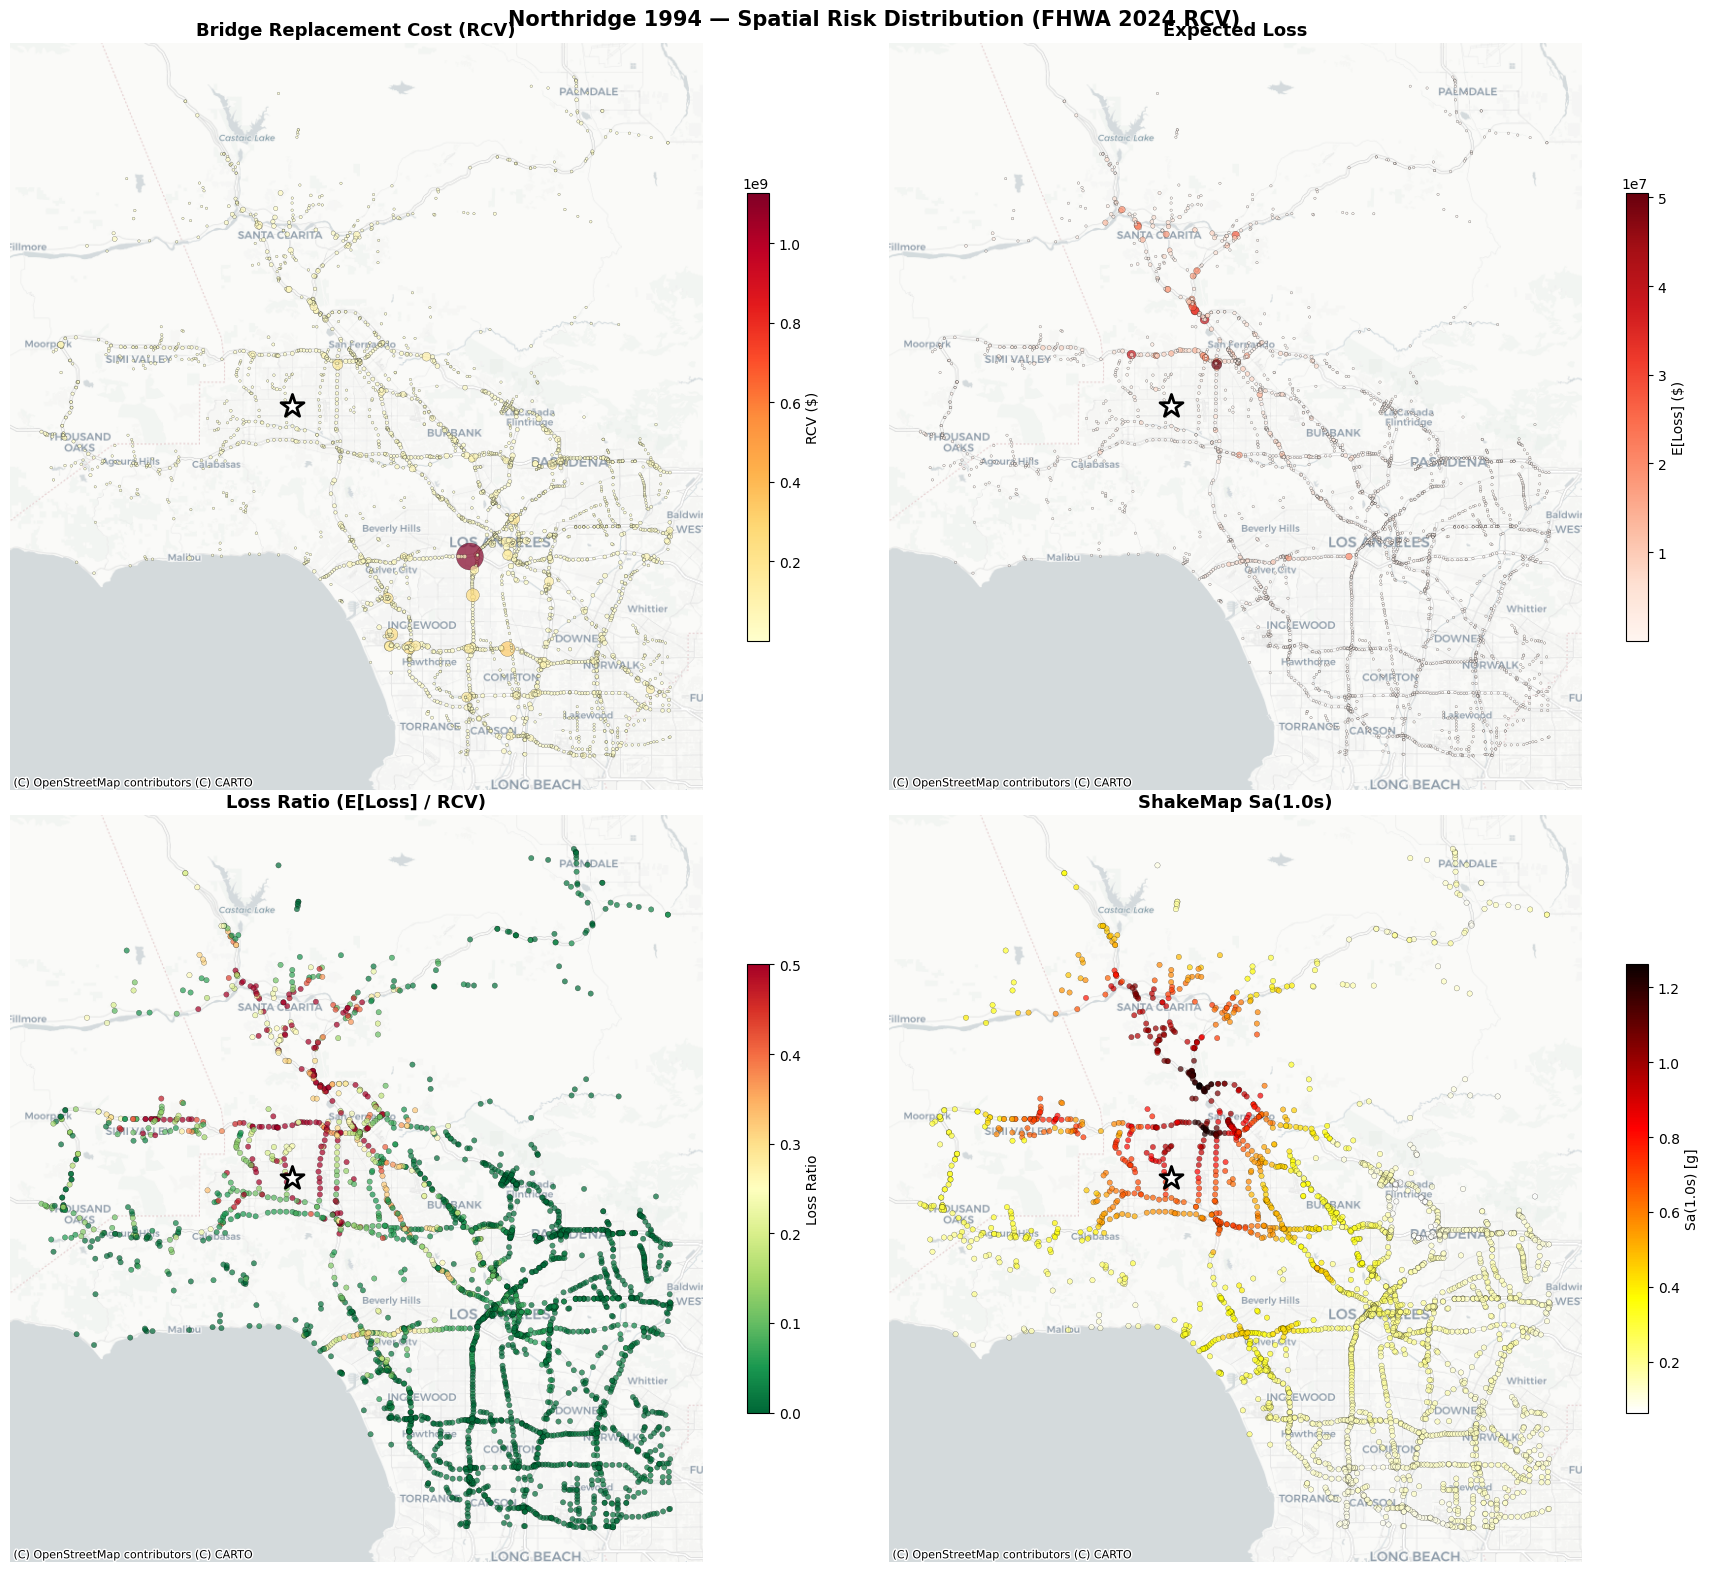

Study area: 2,953 bridges
Total RCV: $28.88B | Total E[Loss]: $2.60B (9.0%)


In [8]:
import geopandas as gpd
import contextily as cx
from shapely.geometry import Point

# Build GeoDataFrame
loss_df["latitude"] = nbi["latitude"].values
loss_df["longitude"] = nbi["longitude"].values
loss_df["sa"] = sa_arr

geometry = [Point(xy) for xy in zip(loss_df["longitude"], loss_df["latitude"])]
gdf = gpd.GeoDataFrame(loss_df, geometry=geometry, crs="EPSG:4326")
gdf = gdf.to_crs(epsg=3857)  # Web Mercator for basemap

# Epicenter
epi = gpd.GeoDataFrame(
    {"name": ["Epicenter"]},
    geometry=[Point(-118.537, 34.213)], crs="EPSG:4326"
).to_crs(epsg=3857)

fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# ── Panel 1: RCV Map ──
ax = axes[0, 0]
gdf.plot(ax=ax, column="rcv", cmap="YlOrRd", markersize=gdf["rcv"]/3e6 + 3,
         alpha=0.7, edgecolor="k", linewidth=0.2, legend=True,
         legend_kwds={"label": "RCV ($)", "shrink": 0.6})
epi.plot(ax=ax, marker="*", color="white", markersize=300, edgecolor="k", linewidth=2, zorder=10)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=10)
ax.set_title("Bridge Replacement Cost (RCV)", fontsize=13, fontweight="bold")
ax.set_axis_off()

# ── Panel 2: Expected Loss Map ──
ax = axes[0, 1]
gdf.plot(ax=ax, column="expected_loss", cmap="Reds", markersize=gdf["expected_loss"]/1e6 + 3,
         alpha=0.7, edgecolor="k", linewidth=0.2, legend=True,
         legend_kwds={"label": "E[Loss] ($)", "shrink": 0.6})
epi.plot(ax=ax, marker="*", color="white", markersize=300, edgecolor="k", linewidth=2, zorder=10)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=10)
ax.set_title("Expected Loss", fontsize=13, fontweight="bold")
ax.set_axis_off()

# ── Panel 3: Loss Ratio Map ──
ax = axes[1, 0]
gdf.plot(ax=ax, column="loss_ratio", cmap="RdYlGn_r", markersize=15,
         alpha=0.7, edgecolor="k", linewidth=0.2, vmin=0, vmax=0.5,
         legend=True, legend_kwds={"label": "Loss Ratio", "shrink": 0.6})
epi.plot(ax=ax, marker="*", color="white", markersize=300, edgecolor="k", linewidth=2, zorder=10)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=10)
ax.set_title("Loss Ratio (E[Loss] / RCV)", fontsize=13, fontweight="bold")
ax.set_axis_off()

# ── Panel 4: Sa Ground Motion Map ──
ax = axes[1, 1]
gdf.plot(ax=ax, column="sa", cmap="hot_r", markersize=15,
         alpha=0.7, edgecolor="k", linewidth=0.2,
         legend=True, legend_kwds={"label": "Sa(1.0s) [g]", "shrink": 0.6})
epi.plot(ax=ax, marker="*", color="white", markersize=300, edgecolor="k", linewidth=2, zorder=10)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=10)
ax.set_title("ShakeMap Sa(1.0s)", fontsize=13, fontweight="bold")
ax.set_axis_off()

plt.suptitle("Northridge 1994 — Spatial Risk Distribution (FHWA 2024 RCV)",
             fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

print(f"Study area: {len(loss_df):,} bridges")
print(f"Total RCV: ${total_rcv/1e9:.2f}B | Total E[Loss]: ${total_loss/1e9:.2f}B ({total_loss/total_rcv:.1%})")

## Step 8: Loss Distribution Charts

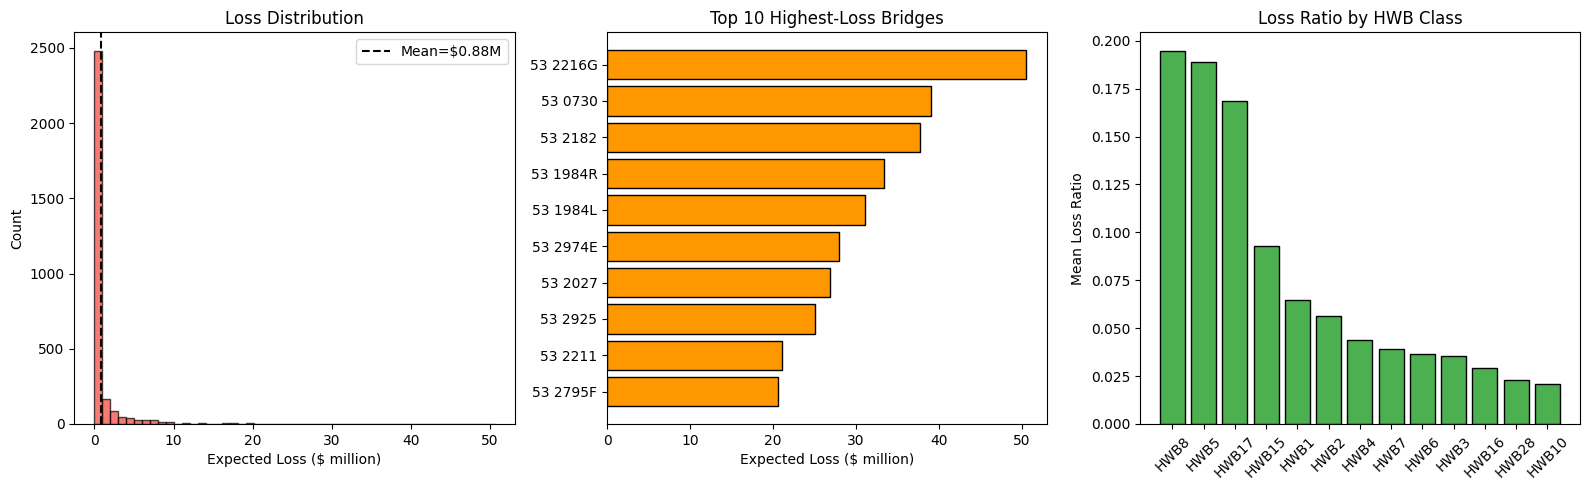

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss histogram
ax = axes[0]
ax.hist(loss_df["expected_loss"]/1e6, bins=50, color="#F44336", edgecolor="k", alpha=0.7)
ax.set_xlabel("Expected Loss ($ million)")
ax.set_ylabel("Count")
ax.set_title("Loss Distribution")
ax.axvline(loss_df["expected_loss"].mean()/1e6, color="k", ls="--",
           label=f"Mean=${loss_df['expected_loss'].mean()/1e6:.2f}M")
ax.legend()

# Top 10 bridges
ax = axes[1]
top10 = loss_df.nlargest(10, "expected_loss")
ax.barh(range(10), top10["expected_loss"]/1e6, color="#FF9800", edgecolor="k")
ax.set_yticks(range(10))
ax.set_yticklabels(top10["bridge"].values)
ax.set_xlabel("Expected Loss ($ million)")
ax.set_title("Top 10 Highest-Loss Bridges")
ax.invert_yaxis()

# Loss ratio by HWB class
ax = axes[2]
lr_by_hwb = loss_df.groupby("hwb")["loss_ratio"].mean().sort_values(ascending=False)
ax.bar(range(len(lr_by_hwb)), lr_by_hwb.values, color="#4CAF50", edgecolor="k")
ax.set_xticks(range(len(lr_by_hwb)))
ax.set_xticklabels(lr_by_hwb.index, rotation=45)
ax.set_ylabel("Mean Loss Ratio")
ax.set_title("Loss Ratio by HWB Class")

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the full loss calculation pipeline:

1. **FHWA 2024 Cost Model** -- state-level bridge replacement unit costs ($5,005/m2 for California NHS bridges)
2. **Adjustment Factors** -- material (0.65-1.15x), span complexity (1.0-1.5x), skew angle (1.0-1.2x), seismic era (1.0-1.15x)
3. **NBI-to-RCV Conversion** -- computed replacement costs for ~2,953 bridges using both legacy and FHWA models
4. **Hazus Damage Ratios** -- Table 7.11 maps damage states to repair cost fractions (0%-100% of RCV)
5. **Expected Loss** -- combined fragility probabilities with damage ratios and RCV for portfolio-level loss estimates

### Data Sources & References

| Data | Source | URL / Citation |
|------|--------|----------------|
| Bridge replacement unit costs ($/ft2 by state) | FHWA Bridge Replacement Unit Costs 2024 | [fhwa.dot.gov/bridge/nbi/sd2024.cfm](https://www.fhwa.dot.gov/bridge/nbi/sd2024.cfm) |
| Unit cost methodology | FHWA Unit Cost Explanation | [fhwa.dot.gov/bridge/nbi/uc_explain.cfm](https://www.fhwa.dot.gov/bridge/nbi/uc_explain.cfm) |
| Material cost factors | Caltrans Comparative Bridge Costs 2022 | [dot.ca.gov (comp-br-costs-2022.pdf)](https://dot.ca.gov/-/media/dot-media/programs/local-assistance/documents/hbp/2024/comp-br-costs-2022.pdf) |
| Span/skew adjustment factors | Mackie & Stojadinovic (2010) | Earthquake Eng. & Structural Dynamics, 39(3), 281-301. [DOI](https://doi.org/10.1002/eqe.942) |
| Damage ratios (Table 7.11) | FEMA Hazus 6.1 Earthquake Technical Manual | [fema.gov/hazus](https://www.fema.gov/flood-maps/products-tools/hazus) |
| NBI bridge inventory | FHWA National Bridge Inventory 2024 | [fhwa.dot.gov/bridge/nbi.cfm](https://www.fhwa.dot.gov/bridge/nbi.cfm) |
| Bridge repair cost models | Padgett & DesRoches (2007) | Earthquake Spectra, 23(1), 115-130 |
| Seismic risk methodology | Werner et al. (2006) REDARS 2 | MCEER-06-SP08. [ROSAP](https://rosap.ntl.bts.gov/view/dot/27638) |

### NBI Fields Used for RCV Estimation

| NBI Item | Column | Use |
|----------|--------|-----|
| 049 | STRUCTURE_LEN_MT_049 | Deck area (length x width) |
| 052 | DECK_WIDTH_MT_052 | Deck area (length x width) |
| 043A | STRUCTURE_KIND_043A | Material factor lookup |
| 048 | MAX_SPAN_LEN_MT_048 | Span complexity factor |
| 034 | DEGREES_SKEW_034 | Skew construction factor |
| 027 | YEAR_BUILT_027 | Seismic design era factor |

**Previous:** [05_validation.ipynb](05_validation.ipynb) -- Validation against Northridge observations

## Step 9: Risk Analytics Dashboard

Practical charts for different stakeholders:
- **Insurance analyst:** Loss exceedance curve, portfolio loss ratio
- **Transportation planner:** Retrofit priority ranking, loss by bridge type
- **Emergency manager:** Downtime impact, damage state breakdown

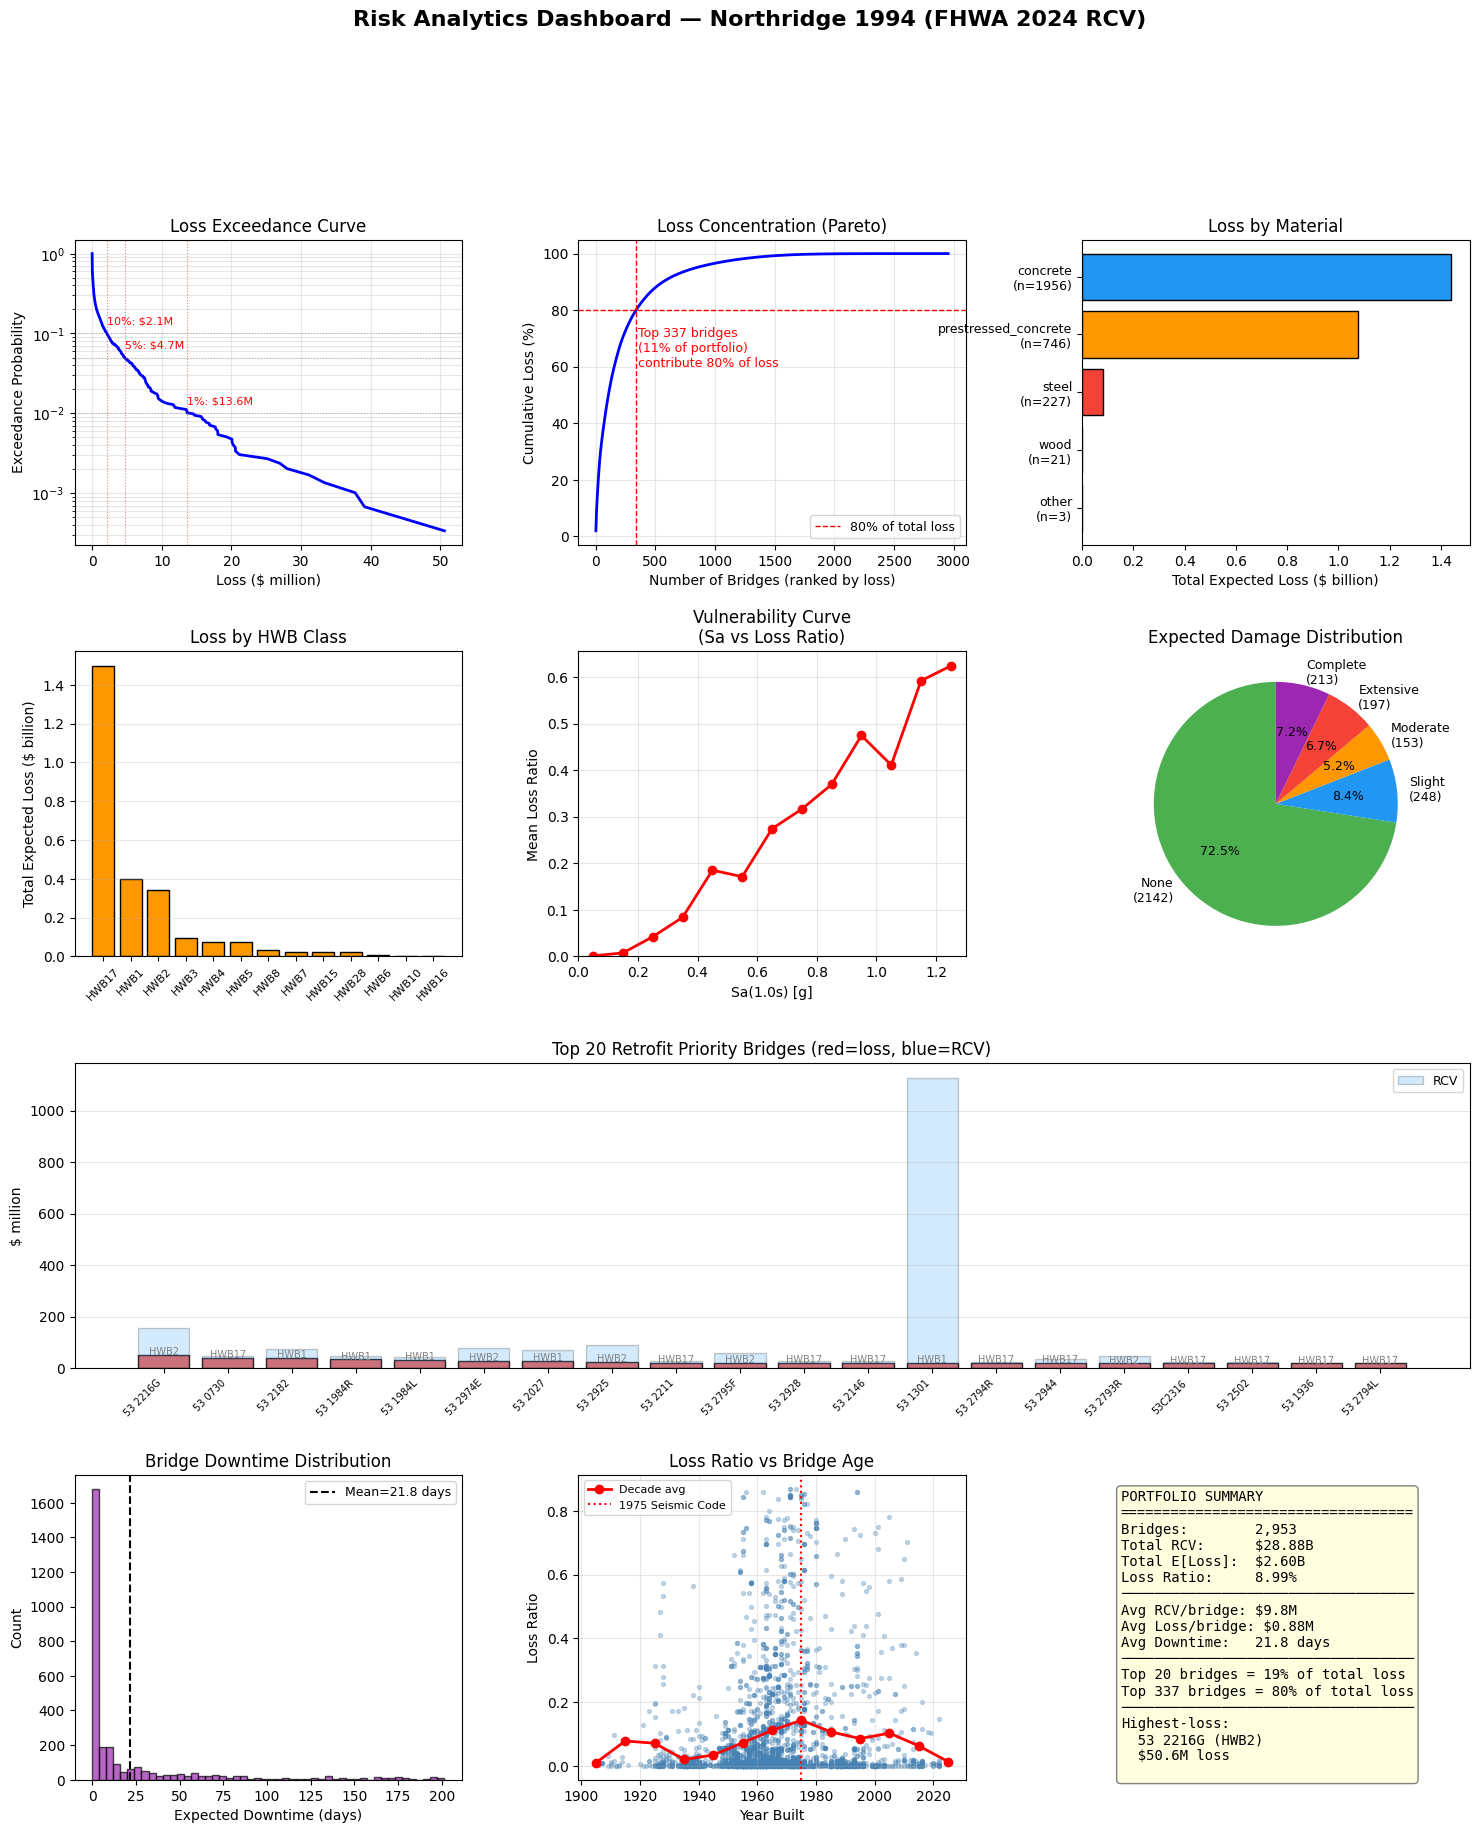

Dashboard saved to: output/analysis/risk_dashboard.png


In [10]:
fig = plt.figure(figsize=(18, 20))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

# ── 1. Loss Exceedance Curve (EP Curve) ──────────────────────────
ax = fig.add_subplot(gs[0, 0])
sorted_loss = np.sort(loss_df["expected_loss"].values)[::-1]
exceed_prob = np.arange(1, len(sorted_loss) + 1) / len(sorted_loss)
ax.semilogy(sorted_loss / 1e6, exceed_prob, "b-", lw=2)
ax.set_xlabel("Loss ($ million)")
ax.set_ylabel("Exceedance Probability")
ax.set_title("Loss Exceedance Curve")
ax.grid(True, alpha=0.3, which="both")
# Mark key percentiles
for pct, label in [(0.01, "1%"), (0.05, "5%"), (0.10, "10%")]:
    idx = int(pct * len(sorted_loss))
    if idx < len(sorted_loss):
        ax.axhline(pct, color="gray", ls=":", lw=0.8, alpha=0.5)
        ax.axvline(sorted_loss[idx]/1e6, color="red", ls=":", lw=0.8, alpha=0.5)
        ax.text(sorted_loss[idx]/1e6, pct*1.3, f"{label}: ${sorted_loss[idx]/1e6:.1f}M",
                fontsize=8, color="red")

# ── 2. Cumulative Loss Contribution ──────────────────────────────
ax = fig.add_subplot(gs[0, 1])
sorted_by_loss = loss_df.sort_values("expected_loss", ascending=False)
cumulative = sorted_by_loss["expected_loss"].cumsum() / total_loss * 100
ax.plot(range(1, len(cumulative)+1), cumulative.values, "b-", lw=2)
ax.axhline(80, color="red", ls="--", lw=1, label="80% of total loss")
n_80 = (cumulative <= 80).sum()
ax.axvline(n_80, color="red", ls="--", lw=1)
ax.text(n_80+20, 60, f"Top {n_80} bridges\n({n_80/len(loss_df)*100:.0f}% of portfolio)\ncontribute 80% of loss",
        fontsize=9, color="red")
ax.set_xlabel("Number of Bridges (ranked by loss)")
ax.set_ylabel("Cumulative Loss (%)")
ax.set_title("Loss Concentration (Pareto)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── 3. Loss by Material Type ────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
mat_loss = loss_df.groupby("material").agg(
    total_loss=("expected_loss", "sum"),
    total_rcv=("rcv", "sum"),
    count=("bridge", "count")
).sort_values("total_loss", ascending=True)
colors_mat = {"concrete": "#2196F3", "steel": "#F44336",
              "prestressed_concrete": "#FF9800", "wood": "#4CAF50", "other": "#9E9E9E"}
bar_colors = [colors_mat.get(m, "#9E9E9E") for m in mat_loss.index]
ax.barh(range(len(mat_loss)), mat_loss["total_loss"]/1e9, color=bar_colors, edgecolor="k")
ax.set_yticks(range(len(mat_loss)))
ax.set_yticklabels([f"{m}\n(n={mat_loss.loc[m,'count']})" for m in mat_loss.index], fontsize=9)
ax.set_xlabel("Total Expected Loss ($ billion)")
ax.set_title("Loss by Material")

# ── 4. Loss by HWB Class ────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
hwb_stats = loss_df.groupby("hwb").agg(
    total_loss=("expected_loss", "sum"),
    mean_ratio=("loss_ratio", "mean"),
    count=("bridge", "count")
).sort_values("total_loss", ascending=False)
ax.bar(range(len(hwb_stats)), hwb_stats["total_loss"]/1e9, color="#FF9800", edgecolor="k")
ax.set_xticks(range(len(hwb_stats)))
ax.set_xticklabels(hwb_stats.index, rotation=45, fontsize=8)
ax.set_ylabel("Total Expected Loss ($ billion)")
ax.set_title("Loss by HWB Class")
ax.grid(axis="y", alpha=0.3)

# ── 5. Sa vs Loss Ratio (vulnerability curve) ───────────────────
ax = fig.add_subplot(gs[1, 1])
sa_bins = np.arange(0, 1.4, 0.1)
bin_centers = (sa_bins[:-1] + sa_bins[1:]) / 2
binned = pd.cut(loss_df["sa"], sa_bins)
lr_by_sa = loss_df.groupby(binned, observed=True)["loss_ratio"].mean()
ax.plot(bin_centers[:len(lr_by_sa)], lr_by_sa.values, "ro-", lw=2, markersize=6)
ax.set_xlabel("Sa(1.0s) [g]")
ax.set_ylabel("Mean Loss Ratio")
ax.set_title("Vulnerability Curve\n(Sa vs Loss Ratio)")
ax.set_xlim(0, 1.3)
ax.set_ylim(0, None)
ax.grid(True, alpha=0.3)

# ── 6. Damage State Breakdown (portfolio pie) ───────────────────
ax = fig.add_subplot(gs[1, 2])
# Compute portfolio-level expected damage counts
ds_counts = {}
for ds in ds_order:
    ds_counts[ds] = 0
for i, (_, row) in enumerate(nbi.iterrows()):
    probs = damage_state_probabilities(sa_arr[i], row["hwb_class"])
    for ds in ds_order:
        ds_counts[ds] += probs[ds]
pie_colors = ["#4CAF50", "#2196F3", "#FF9800", "#F44336", "#9C27B0"]
wedges, texts, autotexts = ax.pie(
    [ds_counts[ds] for ds in ds_order],
    labels=[f"{ds.capitalize()}\n({ds_counts[ds]:.0f})" for ds in ds_order],
    colors=pie_colors, autopct="%1.1f%%", startangle=90, textprops={"fontsize": 9}
)
ax.set_title("Expected Damage Distribution")

# ── 7. Retrofit Priority (top 20) ───────────────────────────────
ax = fig.add_subplot(gs[2, :])
top20 = loss_df.nlargest(20, "expected_loss")
x = range(len(top20))
bars = ax.bar(x, top20["expected_loss"]/1e6, color="#F44336", edgecolor="k", alpha=0.8)
ax.bar(x, top20["rcv"]/1e6, color="#2196F3", edgecolor="k", alpha=0.2, label="RCV")
ax.set_xticks(x)
ax.set_xticklabels(top20["bridge"].values, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("$ million")
ax.set_title("Top 20 Retrofit Priority Bridges (red=loss, blue=RCV)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
# Add HWB class labels
for i, (_, r) in enumerate(top20.iterrows()):
    ax.text(i, r["expected_loss"]/1e6 + 0.5, r["hwb"], ha="center", fontsize=7, color="gray")

# ── 8. Downtime Impact ──────────────────────────────────────────
ax = fig.add_subplot(gs[3, 0])
# Expected downtime per bridge
downtime_results = []
for i, (_, row) in enumerate(nbi.iterrows()):
    probs = damage_state_probabilities(sa_arr[i], row["hwb_class"])
    dt = sum(probs[ds] * HAZUS_DOWNTIME_DAYS[ds] for ds in ds_order)
    downtime_results.append(dt)
loss_df["expected_downtime_days"] = downtime_results
ax.hist(loss_df["expected_downtime_days"], bins=50, color="#9C27B0", edgecolor="k", alpha=0.7)
ax.set_xlabel("Expected Downtime (days)")
ax.set_ylabel("Count")
ax.set_title("Bridge Downtime Distribution")
ax.axvline(loss_df["expected_downtime_days"].mean(), color="k", ls="--",
           label=f"Mean={loss_df['expected_downtime_days'].mean():.1f} days")
ax.legend(fontsize=9)

# ── 9. Loss Ratio vs Bridge Age ──────────────────────────────────
ax = fig.add_subplot(gs[3, 1])
loss_df["year_built"] = nbi["year_built"].values
ax.scatter(loss_df["year_built"], loss_df["loss_ratio"], s=8, alpha=0.3, c="steelblue")
# Decade averages
decade_avg = loss_df.groupby((loss_df["year_built"] // 10) * 10)["loss_ratio"].mean()
ax.plot(decade_avg.index + 5, decade_avg.values, "ro-", lw=2, markersize=6, label="Decade avg")
ax.axvline(1975, color="red", ls=":", lw=1.5, label="1975 Seismic Code")
ax.set_xlabel("Year Built")
ax.set_ylabel("Loss Ratio")
ax.set_title("Loss Ratio vs Bridge Age")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── 10. Portfolio Summary Box ────────────────────────────────────
ax = fig.add_subplot(gs[3, 2])
ax.axis("off")
summary_text = (
    f"PORTFOLIO SUMMARY\n"
    f"{'='*35}\n"
    f"Bridges:        {len(loss_df):,}\n"
    f"Total RCV:      ${total_rcv/1e9:.2f}B\n"
    f"Total E[Loss]:  ${total_loss/1e9:.2f}B\n"
    f"Loss Ratio:     {total_loss/total_rcv:.2%}\n"
    f"{'─'*35}\n"
    f"Avg RCV/bridge: ${total_rcv/len(loss_df)/1e6:.1f}M\n"
    f"Avg Loss/bridge: ${total_loss/len(loss_df)/1e6:.2f}M\n"
    f"Avg Downtime:   {loss_df['expected_downtime_days'].mean():.1f} days\n"
    f"{'─'*35}\n"
    f"Top 20 bridges = {top20['expected_loss'].sum()/total_loss:.0%} of total loss\n"
    f"Top {n_80} bridges = 80% of total loss\n"
    f"{'─'*35}\n"
    f"Highest-loss:\n"
    f"  {top20.iloc[0]['bridge']} ({top20.iloc[0]['hwb']})\n"
    f"  ${top20.iloc[0]['expected_loss']/1e6:.1f}M loss\n"
)
ax.text(0.1, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

plt.suptitle("Risk Analytics Dashboard — Northridge 1994 (FHWA 2024 RCV)",
             fontsize=16, fontweight="bold", y=0.995)
plt.savefig(PROJECT_ROOT / "output" / "analysis" / "risk_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("Dashboard saved to: output/analysis/risk_dashboard.png")